In [1]:
import mysql.connector
import pandas as pd

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",        
    user="root",            
    password="Aditya06.com",
    database="retail_sales_analysis"   
)
query = "SELECT * FROM superstore;"
df = pd.read_sql(query, conn)
conn.close()
df.to_csv("clean_data.xlsx",index=False)

print(df.head(5))


C:\Users\ADITYA PANDA\AppData\Local\Temp\ipykernel_6264\2972430789.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


   row_id        order_id       ship_mode customer_id    customer_name  \
0       1  CA-2016-152156    Second Class    CG-12520      Claire Gute   
1       2  CA-2016-152156    Second Class    CG-12520      Claire Gute   
2       3  CA-2016-138688    Second Class    DV-13045  Darrin Van Huff   
3       4  US-2015-108966  Standard Class    SO-20335   Sean O'Donnell   
4       5  US-2015-108966  Standard Class    SO-20335   Sean O'Donnell   

     segment        country             city       state postal_code  ...  \
0   Consumer  United States        Henderson    Kentucky       42420  ...   
1   Consumer  United States        Henderson    Kentucky       42420  ...   
2  Corporate  United States      Los Angeles  California       90036  ...   
3   Consumer  United States  Fort Lauderdale     Florida       33311  ...   
4   Consumer  United States  Fort Lauderdale     Florida       33311  ...   

        product_id         category sub_category  \
0  FUR-BO-10001798        Furniture    B

In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   str    
 2   ship_mode      9994 non-null   str    
 3   customer_id    9994 non-null   str    
 4   customer_name  9994 non-null   str    
 5   segment        9994 non-null   str    
 6   country        9994 non-null   str    
 7   city           9994 non-null   str    
 8   state          9994 non-null   str    
 9   postal_code    9994 non-null   str    
 10  region         9994 non-null   str    
 11  product_id     9994 non-null   str    
 12  category       9994 non-null   str    
 13  sub_category   9994 non-null   str    
 14  product_name   9994 non-null   str    
 15  sales          9994 non-null   float64
 16  quantity       9994 non-null   int64  
 17  discount       9994 non-null   float64
 18  profit         9994

In [3]:
df["order_date"]=pd.to_datetime(df["order_date"])
df["ship_date"]=pd.to_datetime(df["ship_date"])

In [4]:
print(df.dtypes)

row_id                   int64
order_id                   str
ship_mode                  str
customer_id                str
customer_name              str
segment                    str
country                    str
city                       str
state                      str
postal_code                str
region                     str
product_id                 str
category                   str
sub_category               str
product_name               str
sales                  float64
quantity                 int64
discount               float64
profit                 float64
order_date       datetime64[s]
ship_date        datetime64[s]
dtype: object


In [5]:
print(df.isnull().sum())

row_id           0
order_id         0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
order_date       0
ship_date        0
dtype: int64


In [6]:
print(df.duplicated().sum())

0


In [7]:
#create columns :
# Year
df['year']=df['order_date'].dt.year
# Month
df['month']=df['order_date'].dt.month_name()
# Month Number
df['mont_number']=df['order_date'].dt.month
# Quarter
df['quarter']=df['order_date'].dt.quarter
# Delivery Days (Ship Date - Order Date)
df['delivery_date']=(df['ship_date']-df['order_date']).dt.days
# Profit Margin per Order (%)
df['profit_margin']=(df['profit']/df['sales'])*100


In [8]:
df.rename(columns={'mont_number':'month_number'},inplace=True)

In [9]:
print(df.head())

   row_id        order_id       ship_mode customer_id    customer_name  \
0       1  CA-2016-152156    Second Class    CG-12520      Claire Gute   
1       2  CA-2016-152156    Second Class    CG-12520      Claire Gute   
2       3  CA-2016-138688    Second Class    DV-13045  Darrin Van Huff   
3       4  US-2015-108966  Standard Class    SO-20335   Sean O'Donnell   
4       5  US-2015-108966  Standard Class    SO-20335   Sean O'Donnell   

     segment        country             city       state postal_code  ...  \
0   Consumer  United States        Henderson    Kentucky       42420  ...   
1   Consumer  United States        Henderson    Kentucky       42420  ...   
2  Corporate  United States      Los Angeles  California       90036  ...   
3   Consumer  United States  Fort Lauderdale     Florida       33311  ...   
4   Consumer  United States  Fort Lauderdale     Florida       33311  ...   

  discount    profit order_date  ship_date  year     month  month_number  \
0     0.00   41.

Highest Sales Category:
      category     sales
0  Technology  836154.1
Lowest Sales Category:
           category      sales
2  Office Supplies  719046.99


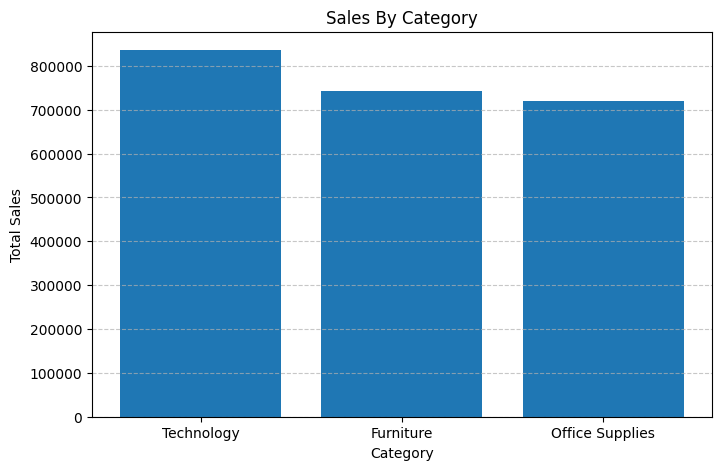

In [10]:
# Visualization Part
import matplotlib.pyplot as plt
# 1.Which category has the highest sales and lowest sales?
sales_by_category=df.groupby('category')['sales'].sum().sort_values(ascending=False).reset_index()
print("Highest Sales Category:\n",sales_by_category.head(1))
print("Lowest Sales Category:\n",sales_by_category.tail(1))
# Chart 1
# Sales by Category bar chart
plt.figure(figsize=(8,5))
plt.bar(sales_by_category['category'],sales_by_category['sales'])
plt.title('Sales By Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("Sales_by_Category.png", dpi=300, bbox_inches='tight')
plt.show()

          category  total_sales  total_profit
0       Technology    836154.10   145454.9481
1        Furniture    741999.98    18451.2728
2  Office Supplies    719046.99   122490.8008


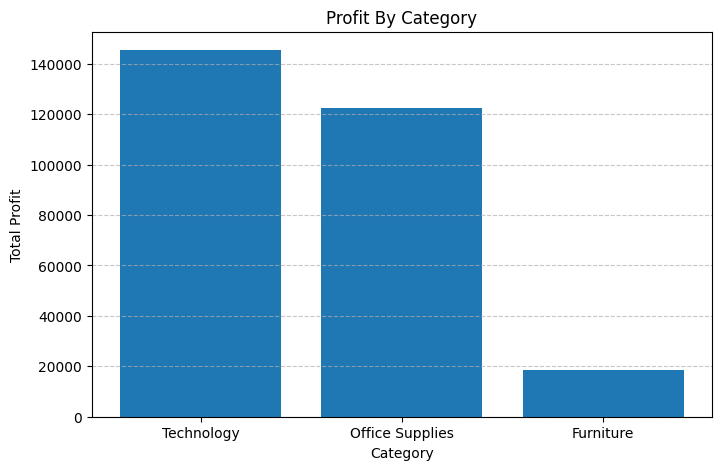

In [32]:
# 2.Which category is the most profitable?
profit_by_category=df.groupby('category')['profit'].sum().sort_values(ascending=False).reset_index()
# print(profit_by_category)
# Is the highest-selling category also the most profitable?
category_summary = (df.groupby('category').agg(total_sales=('sales','sum'),total_profit=('profit','sum'))
.sort_values('total_sales', ascending=False).reset_index()
)
print(category_summary)
# Yes highest-selling category is most profitable

# Chart 2
# Profit by Category Bar Chart
plt.figure(figsize=(8,5))
plt.bar(profit_by_category['category'],profit_by_category['profit'])
plt.title('Profit By Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("Profit_by_Category.png",dpi=300,bbox_inches='tight')
plt.show()

In [12]:
print(df.shape) 

(9994, 27)


In [13]:
# 3 Sales by Region
# Which region has the highest sales?
# Which region has the lowest sales?
region_sales_summary=df.groupby('region')['sales'].sum().round(2).reset_index().sort_values('sales',ascending=False)
print(region_sales_summary)
print("Highest Sales Region:\n",region_sales_summary.head(1))
print("Lowest Sales Region:\n",region_sales_summary.tail(1))

    region      sales
3     West  725457.93
1     East  678781.36
0  Central  501239.88
2    South  391721.90
Highest Sales Region:
   region      sales
3   West  725457.93
Lowest Sales Region:
   region     sales
2  South  391721.9


In [14]:
#4 Profit by Region
# Which region is the most profitable?
# Which region is the least profitable?
region_profit_summary=df.groupby('region')['profit'].sum().reset_index().round(2).sort_values('profit',ascending=False)
print(region_profit_summary)
print("Highest Profit Region:\n",region_profit_summary.head(1))
print("Lowest Profit Region:\n",region_profit_summary.tail(1))

    region     profit
3     West  108418.45
1     East   91522.78
2    South   46749.43
0  Central   39706.36
Highest Profit Region:
   region     profit
3   West  108418.45
Lowest Profit Region:
     region    profit
0  Central  39706.36


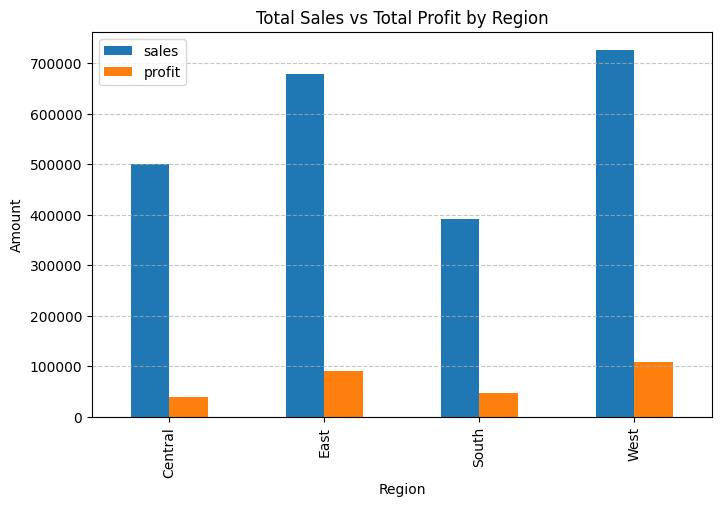

In [33]:
# chart-4 Create a comparison to compare both metrics together with a suitable chart.
summary_data=df.groupby('region')[['sales','profit']].sum().reset_index().round(2)
# print(summary_data)
summary_data.plot(x='region',y=['sales','profit'],kind='bar',figsize=(8,5))
plt.title('Total Sales vs Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.savefig("sales_vs_profit.png",dpi=300,bbox_inches='tight')
plt.show()

In [16]:
# 5 
# Which month has the highest sales?
# Is there any seasonal trend?
month_sales_summary=(df.groupby(['month','month_number','year'])['sales'].sum().reset_index().round(2).sort_values(['year','month_number']))
print(month_sales_summary)
print("Highest Sales\n",month_sales_summary.sort_values('sales',ascending=False).head(1))
print("Lowest Sales\n",month_sales_summary.sort_values('sales',ascending=False).tail(1))
df['year_month'] = df['order_date'].dt.to_period('M').astype(str)

        month  month_number  year      sales
16    January             1  2014   14236.90
12   February             2  2014    4519.92
28      March             3  2014   55691.04
0       April             4  2014   28295.35
32        May             5  2014   23648.28
24       June             6  2014   34595.14
20       July             7  2014   33946.37
4      August             8  2014   27909.47
44  September             9  2014   81777.34
40    October            10  2014   31453.37
36   November            11  2014   78628.74
8    December            12  2014   69545.64
17    January             1  2015   18174.08
13   February             2  2015   11951.40
29      March             3  2015   38726.26
1       April             4  2015   34195.25
33        May             5  2015   30131.72
25       June             6  2015   24797.31
21       July             7  2015   28765.32
5      August             8  2015   36898.32
45  September             9  2015   64595.87
41    Octo

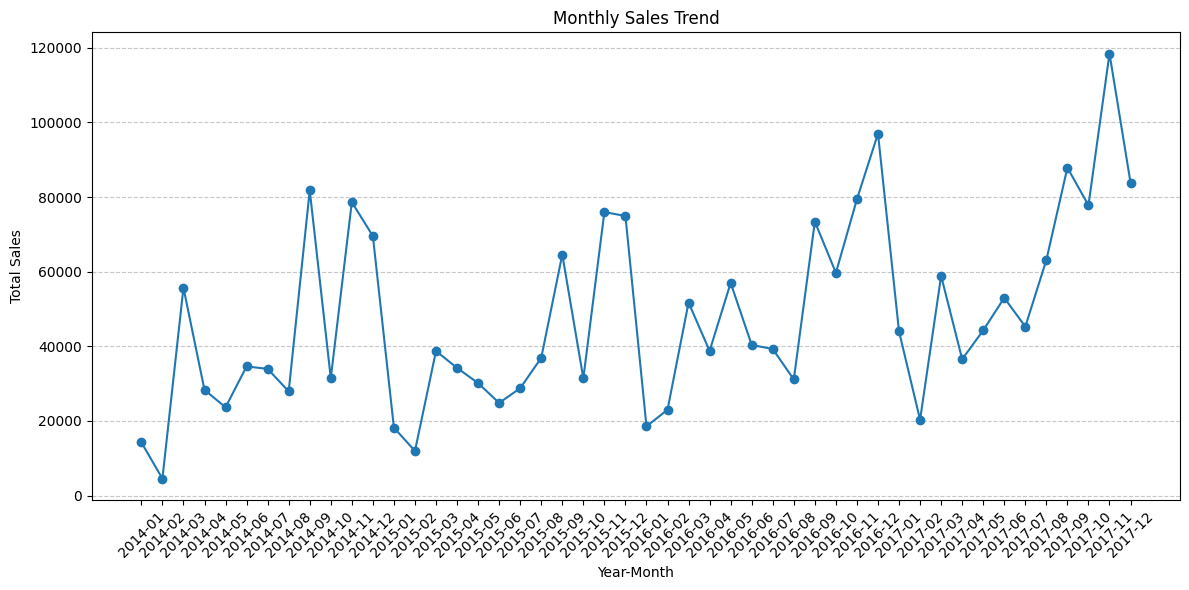

In [17]:
# Chart 5: Monthly Sales Trend
monthly_sales_trend=df.groupby('year_month')['sales'].sum().reset_index().sort_values('year_month')
plt.figure(figsize=(12,6))
plt.plot(monthly_sales_trend['year_month'],monthly_sales_trend['sales'],marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.tight_layout()
plt.savefig("monthly_sales_trend.png",dpi=300,bbox_inches='tight')
plt.show()

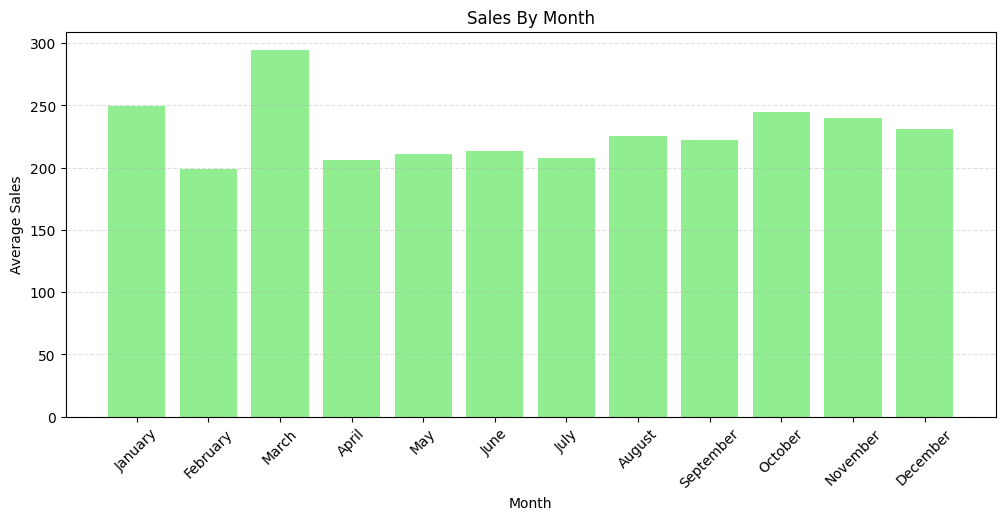

In [18]:
# Chart 6: Average Sales by Month
# df.info()
avg_sales_month =(df.groupby(['month','month_number'])['sales'].mean().round(2).reset_index().sort_values('month_number'))
plt.figure(figsize=(12,5))
plt.bar(avg_sales_month['month'],avg_sales_month['sales'],color='lightgreen')
plt.title('Sales By Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.4)
plt.savefig("avg_sales_by_month.png",dpi=300,bbox_inches='tight')
plt.show()

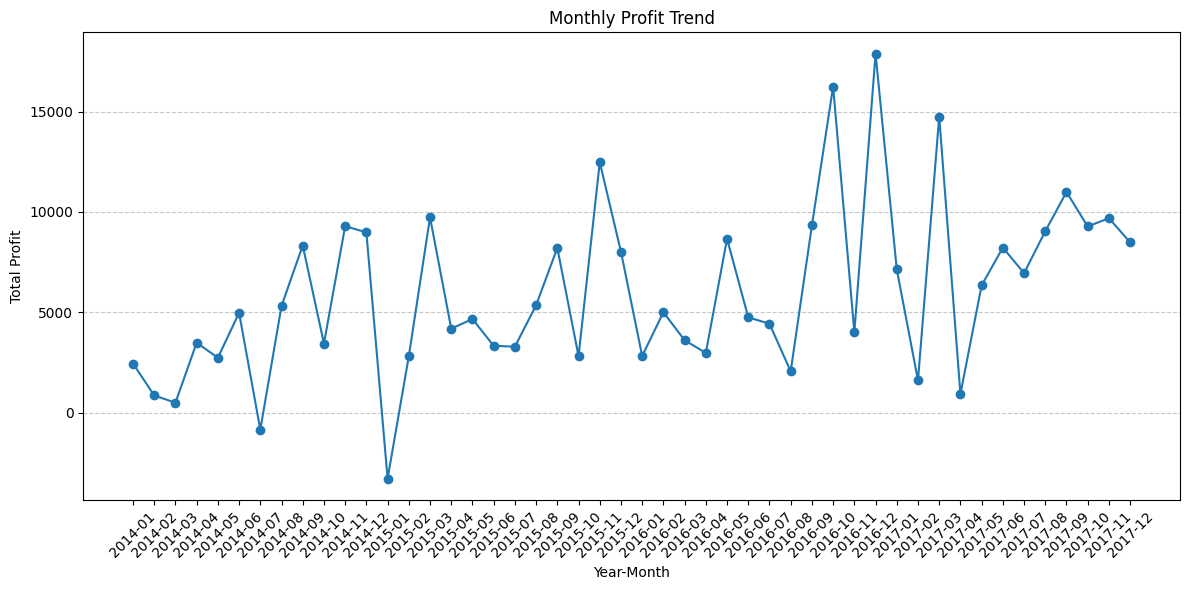

In [19]:
#chart-7 Monthly Profit Trend (Year-Month)
monthly_profit_trend=df.groupby('year_month')['profit'].sum().reset_index().sort_values('year_month')
plt.figure(figsize=(12,6))
plt.plot(monthly_profit_trend['year_month'],monthly_profit_trend['profit'],marker='o')
plt.title("Monthly Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.tight_layout()
plt.savefig("Monthly_Profit_Trend.png",dpi=300,bbox_inches='tight')
plt.show()

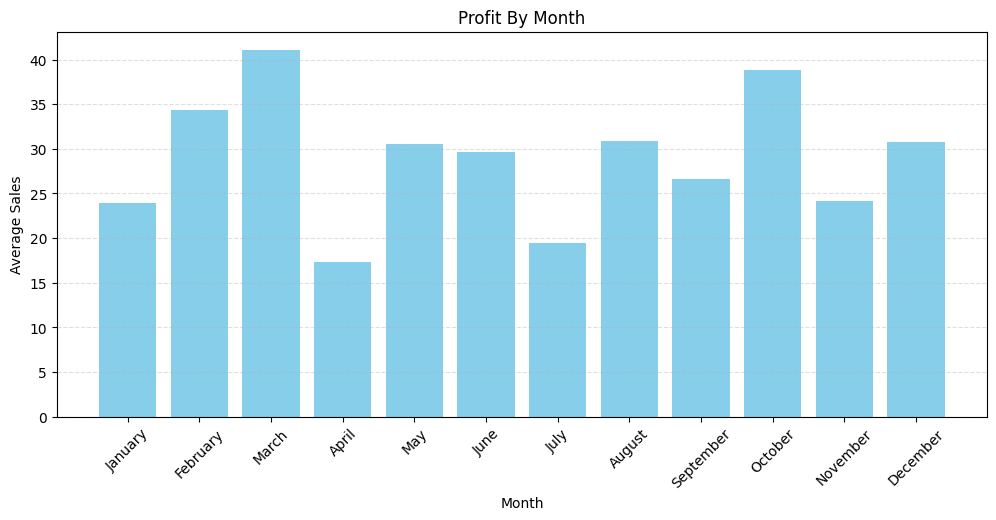

In [20]:
# chart-8 Average Profit by Month (Seasonality)
avg_profit_month =(df.groupby(['month','month_number'])['profit'].mean().round(2).reset_index().sort_values('month_number'))
plt.figure(figsize=(12,5))
plt.bar(avg_profit_month['month'],avg_profit_month['profit'],color='skyBlue')
plt.title('Profit By Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.4)
plt.savefig("Average_Profit_by_Month.png",dpi=300,bbox_inches='tight')
plt.show()

       segment       sales
0     Consumer  1161401.34
1    Corporate   706146.44
2  Home Office   429653.29
Highest Sales Segment: 
     segment       sales
0  Consumer  1161401.34


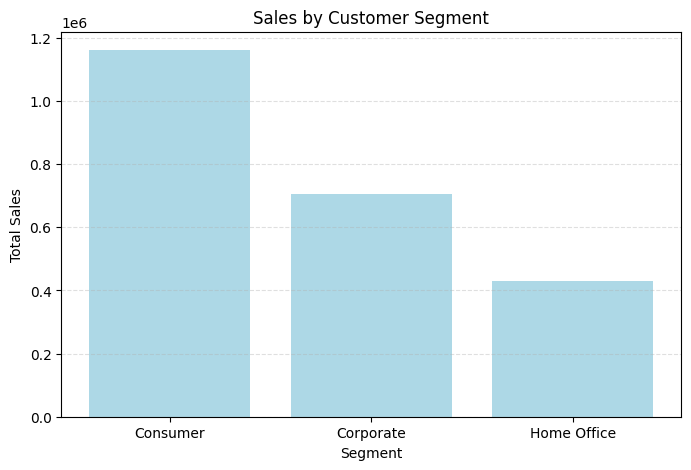

In [21]:
#chart-9 Sales by Customer Segment
# Which segment contributes the most sales
segment_sales=df.groupby('segment')['sales'].sum().round(2).reset_index().sort_values('sales',ascending=False)
print(segment_sales)
print("Highest Sales Segment: \n",segment_sales.head(1))
plt.figure(figsize=(8,5))
plt.bar(segment_sales['segment'],segment_sales['sales'],color='lightblue')
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.grid(axis='y',linestyle='--',alpha=0.4)
plt.savefig("Sales_by_Customer_Segment.png",dpi=300,bbox_inches='tight')
plt.show()

       segment     profit
0     Consumer  134119.21
1    Corporate   91979.13
2  Home Office   60298.68
Highest Profit Segment: 
     segment     profit
0  Consumer  134119.21


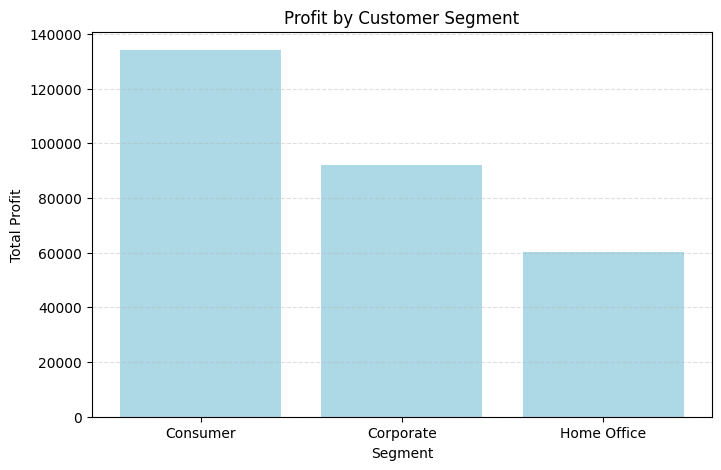

In [22]:
#chart-10 Profit by Customer Segment
# Which segment is the most profitable?
segment_profit=df.groupby('segment')['profit'].sum().round(2).reset_index().sort_values('profit',ascending=False)
print(segment_profit)
print("Highest Profit Segment: \n",segment_profit.head(1))
plt.figure(figsize=(8,5))
plt.bar(segment_profit['segment'],segment_profit['profit'],color='lightblue')
plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")
plt.grid(axis='y',linestyle='--',alpha=0.4)
plt.savefig("Profit_by_Customer_Segment.png",dpi=300,bbox_inches='tight')
plt.show()

       segment       sales     profit
0     Consumer  1161401.34  134119.21
1    Corporate   706146.44   91979.13
2  Home Office   429653.29   60298.68


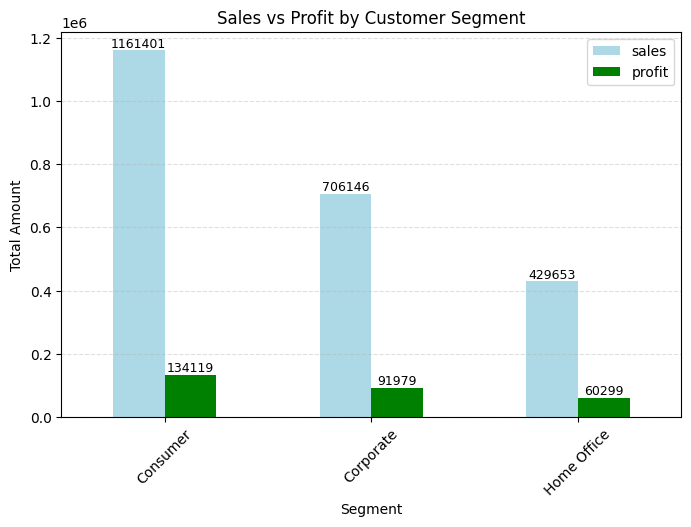

In [23]:
#chart-11 Sales vs Profit by Customer Segment
# Compare both metrics in one chart.
segment_summary=df.groupby('segment')[['sales','profit']].sum().round(2).reset_index().sort_values('sales',ascending=False)
print(segment_summary)
ax=segment_summary.plot(x='segment',y=['sales','profit'],kind='bar',figsize=(8,5),color=['lightblue','green'])
plt.title("Sales vs Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Amount")
plt.grid(axis='y',linestyle='--',alpha=0.4)
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container,fmt='%.0f',label_type='edge',fontsize=9)
plt.savefig("Sales_vs_Profit_by_Customer_Segment.png",dpi=300,bbox_inches='tight')
plt.show()

                                          product_name     sales
404              Canon imageCLASS 2200 Advanced Copier  61599.83
650  Fellowes PB500 Electric Punch Plastic Comb Bin...  27453.38
444  Cisco TelePresence System EX90 Videoconferenci...  22638.48
786       HON 5400 Series Task Chairs for Big and Tall  21870.57
686         GBC DocuBind TL300 Electric Binding System  19823.48
688   GBC Ibimaster 500 Manual ProClick Binding System  19024.50
805               Hewlett Packard LaserJet 3310 Copier  18839.68
787  HP Designjet T520 Inkjet Large Format Printer ...  18374.90
683          GBC DocuBind P400 Electric Binding System  17965.07
813        High Speed Automatic Electric Letter Opener  17030.31


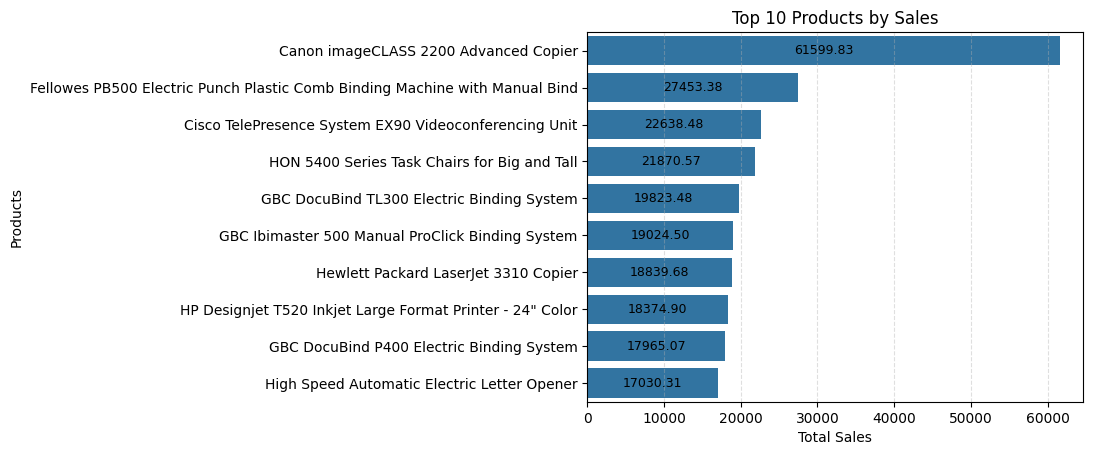

In [24]:
# chart-12 Top 10 Products by Sales
# df.info()
import seaborn as sns
top_sales_products=df.groupby('product_name')['sales'].sum().round(2).reset_index().sort_values('sales',ascending=False).head(10)
print(top_sales_products)

ax=sns.barplot(x='sales',y='product_name',data=top_sales_products)
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Products")
plt.grid(axis='x',linestyle='--',alpha=0.4)


ax.bar_label(ax.containers[0],fmt='%.2f',label_type='center',fontsize=9)
plt.savefig("Top_10_Products_by_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

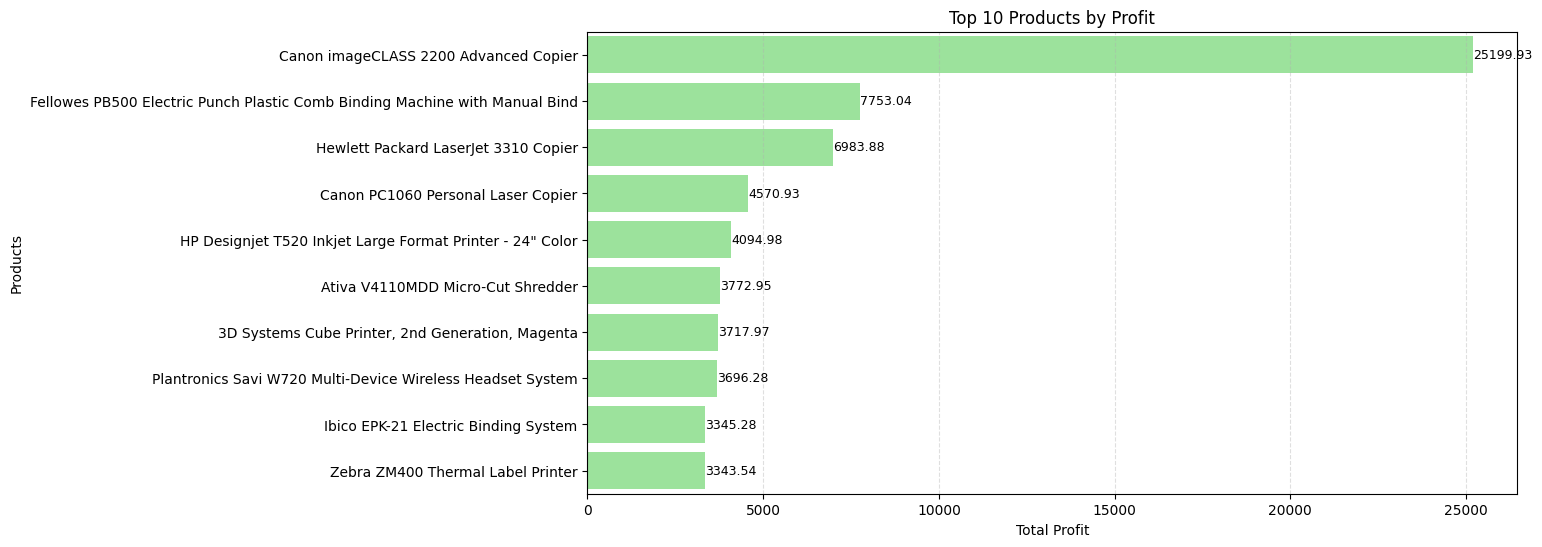

In [25]:
# chart-13 Top 10 Products by Profit
top_profit_products=df.groupby('product_name')['profit'].sum().round(2).reset_index().sort_values('profit',ascending=False).head(10)
# print(top_profit_products)

plt.figure(figsize=(12,6))
ax=sns.barplot(x='profit',y='product_name',data=top_profit_products,color='lightgreen')
plt.title("Top 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Products")
plt.grid(axis='x',linestyle='--',alpha=0.4)

ax.bar_label(ax.containers[0],fmt='%.2f',label_type='edge',fontsize=9)
plt.savefig("Top_10_Products_by_Profit.png",dpi=300,bbox_inches='tight')
plt.show()

                                           product_name  quantity
1499                                            Staples       215
1493                                    Staple envelope       170
537                                   Easy-staple paper       150
1500                            Staples in misc. colors        86
942                          KI Adjustable-Height Table        74
1511                            Storex Dura Pro Binders        71
259                             Avery Non-Stick Binders        71
699   GBC Premium Transparent Covers with Diagonal L...        67
1450         Situations Contoured Folding Chairs, 4/Set        64
1497                         Staple-based wall hangings        62


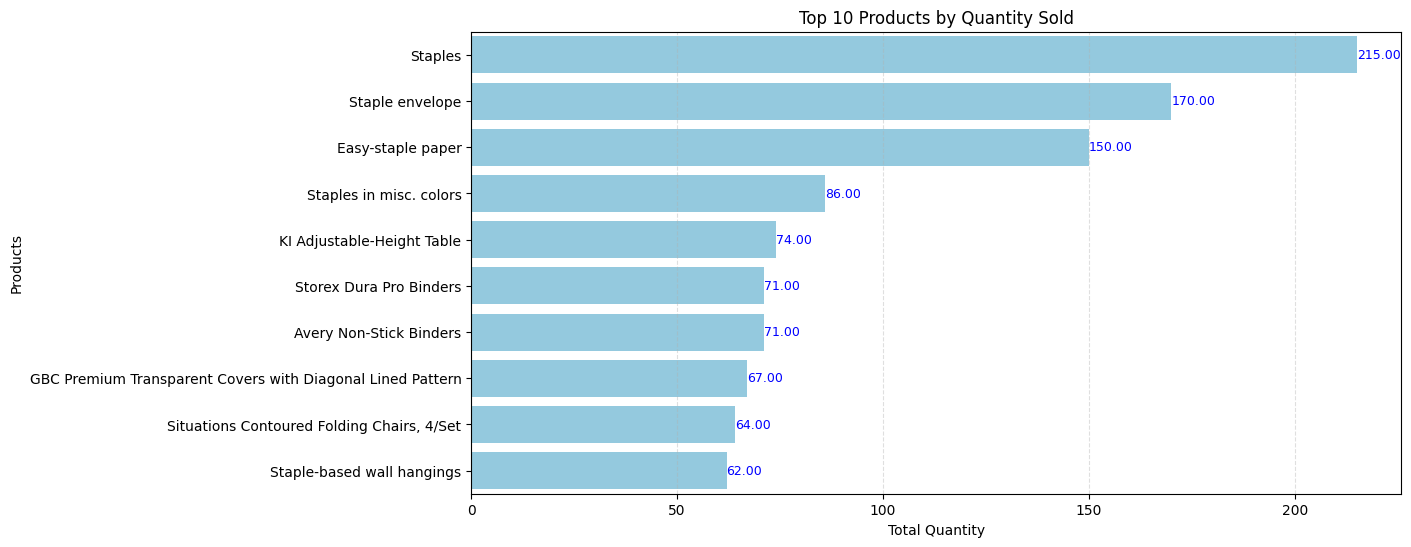

In [26]:
#chart-14  Top 10 Products by Quantity Sold
top_quantity_sold_products=df.groupby('product_name')['quantity'].sum().reset_index().sort_values('quantity',ascending=False).head(10)
print(top_quantity_sold_products)

plt.figure(figsize=(12,6))
ax=sns.barplot(x='quantity',y='product_name',data=top_quantity_sold_products,color='skyblue')
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity")
plt.ylabel("Products")
plt.grid(axis='x',linestyle='--',alpha=0.4)

ax.bar_label(ax.containers[0],fmt='%.2f',label_type='edge',fontsize=9,color='Blue')
plt.savefig("Top_10_Products_by_Quantity(sold).png",dpi=300,bbox_inches='tight')
plt.show()

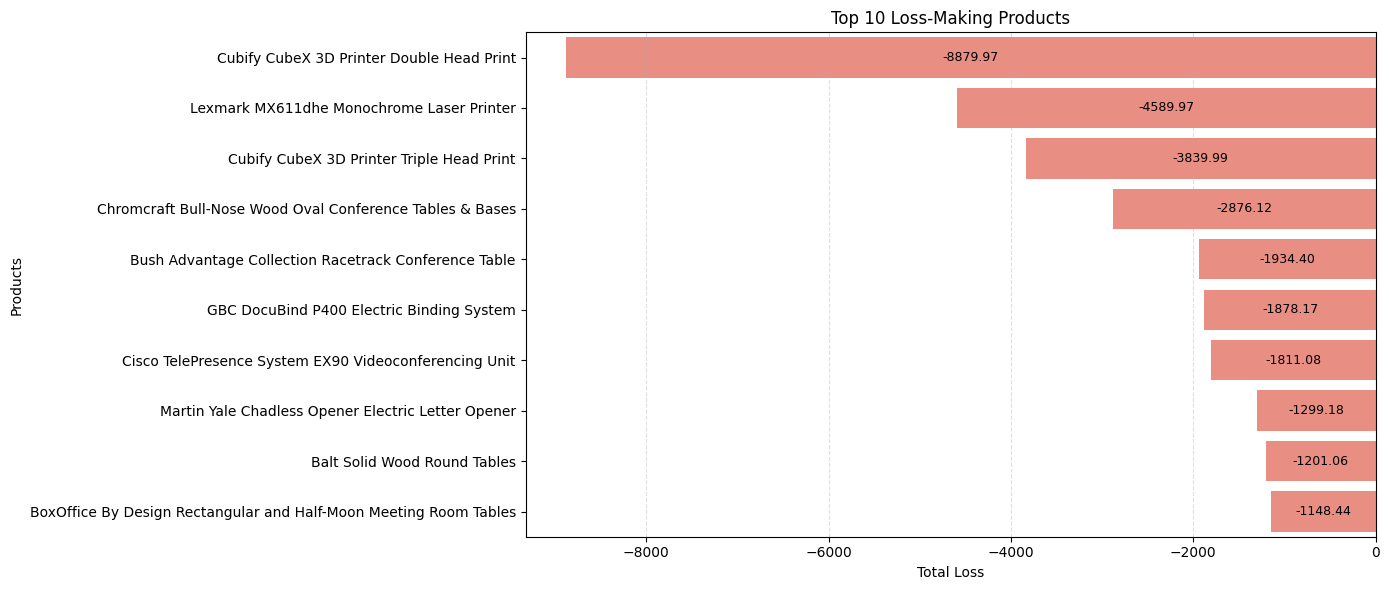

In [27]:
#chart-15 Top 10 Loss-Making Products 
top_loss_making_product=df.groupby('product_name')['profit'].sum().round(2).reset_index().sort_values('profit',ascending=True).head(10)
# print(top_loss_making_product)

plt.figure(figsize=(14,6))
ax=sns.barplot(x='profit',y='product_name',data=top_loss_making_product,color='salmon')
plt.title("Top 10 Loss-Making Products")
plt.xlabel("Total Loss")
plt.ylabel("Products")
plt.grid(axis='x',linestyle='--',alpha=0.4)

ax.bar_label(ax.containers[0],fmt='%.2f',label_type='center',fontsize=9)
plt.tight_layout()
plt.savefig("Top_10_Loss-Making_Products.png",dpi=300,bbox_inches='tight')
plt.show()

Correlation between Discount and Profit: -0.21948745637176834


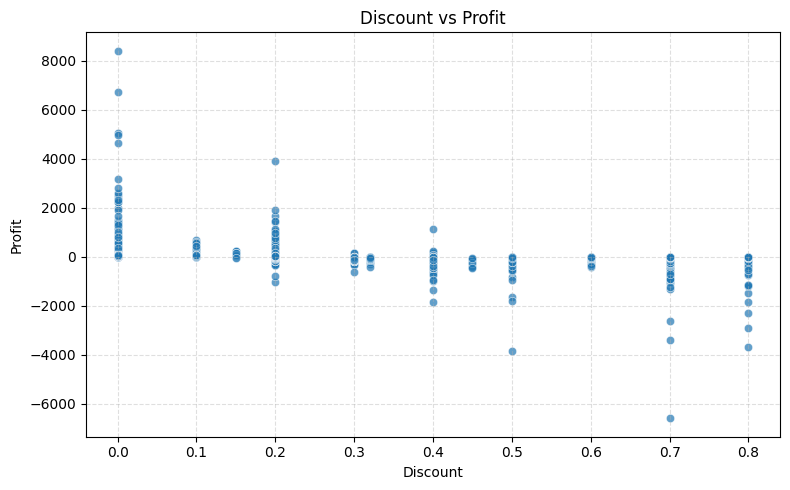

In [28]:
#chart-16 Discount vs Profit
# Does a higher discount reduce profit?
corr=df['discount'].corr(df['profit'])
print("Correlation between Discount and Profit:",corr)

plt.figure(figsize=(8,5))
sns.scatterplot(x='discount',y='profit',data=df,alpha=0.7)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True,linestyle='--',alpha=0.4)
plt.tight_layout()
plt.savefig("Discount_vs_Profit.png",dpi=300,bbox_inches='tight')
plt.show()

Correlation between Sales and Profit: 0.4790643141068617


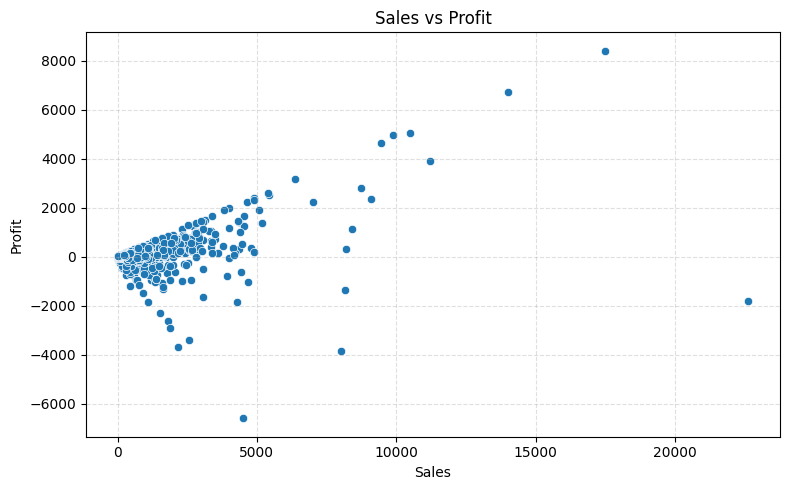

In [29]:
#chart-17 Sales vs Profit
# Is higher sales always associated with higher profit?
corr=df['sales'].corr(df['profit'])
print("Correlation between Sales and Profit:",corr)

plt.figure(figsize=(8,5))
sns.scatterplot(x='sales',y='profit',data=df)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True,linestyle='--',alpha=0.4)
plt.tight_layout()
plt.savefig("Sales_vs_Profit.png",dpi=300,bbox_inches='tight')
plt.show()

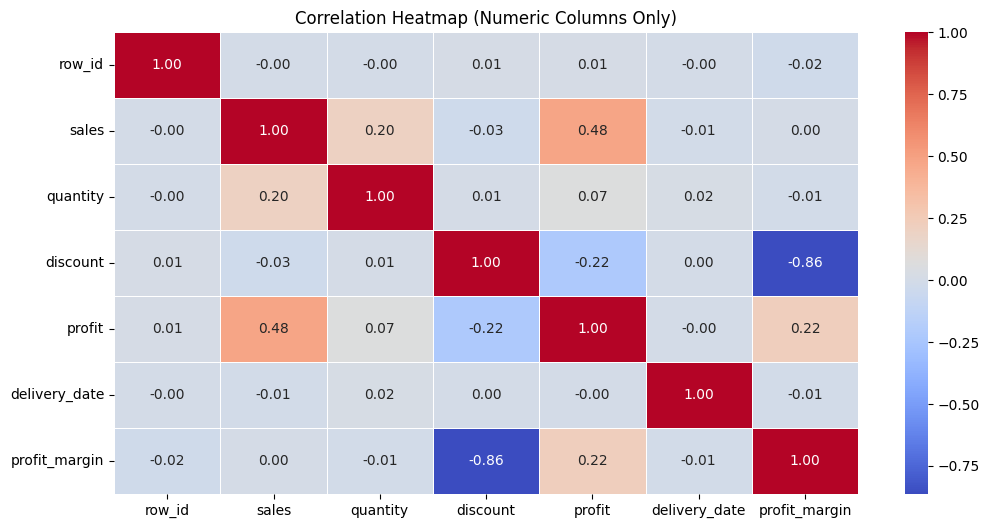

In [30]:
#chart-18 Correlation Heatmap
# Use only numeric columns.
numeric_col=df.select_dtypes(include=['float64','int64'])
corr_matrix=numeric_col.corr()
plt.figure(figsize=(12,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Columns Only)")
plt.savefig("Correlation_Heatmap(numeric_only).png",dpi=300,bbox_inches='tight')
plt.show()

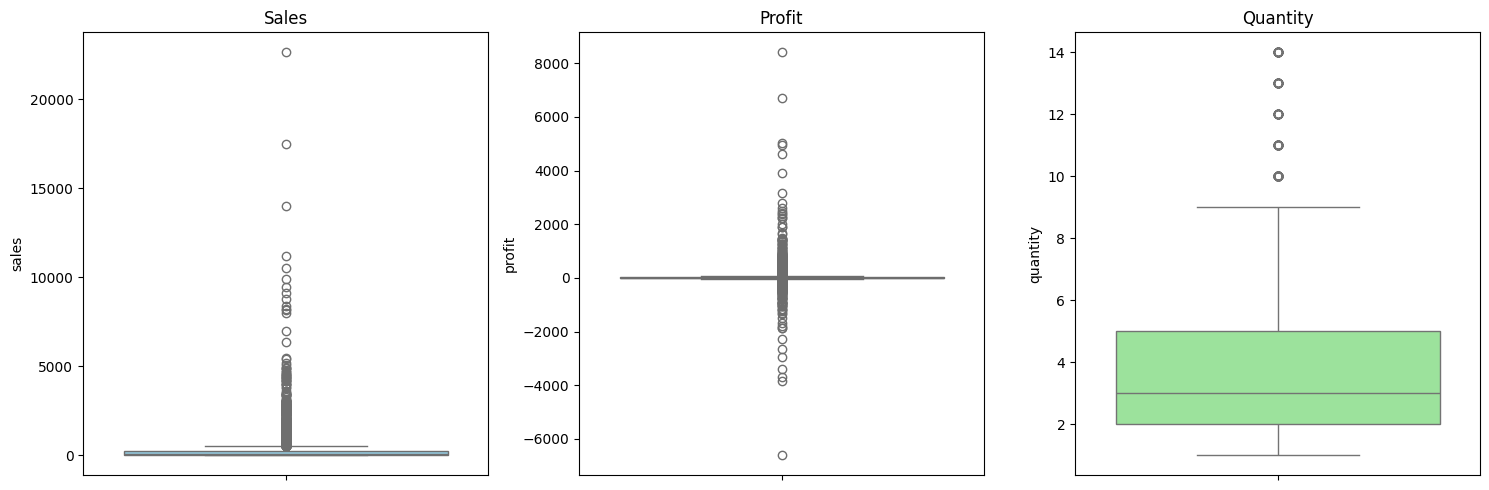

In [31]:
#chart-19  Outlier Detection Sales,Profit,Quantity
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df['sales'],color='skyblue')
plt.title("Sales")

plt.subplot(1,3,2) 
sns.boxplot(y=df['profit'],color='salmon')
plt.title("Profit")

plt.subplot(1,3,3)
sns.boxplot(y=df['quantity'],color='lightgreen')
plt.title("Quantity")

plt.tight_layout()
plt.savefig("Outlier_Detection_Sales_Profit_Quantity.png",dpi=300,bbox_inches='tight')
plt.show()